# W6 — Joint SPX / VIX Calibration of the Heston Model

**Group 4 — Volatility as an Asset Class**  
Computational Finance Course — Stochastic Processes

---

This notebook implements the W6 deliverables:

| # | Task | Status |
|---|------|---------|
| 1 | Load SPX option-chain snapshot | ✅ |
| 2 | Load VIX futures term structure | ✅ |
| 3 | Calibrate Heston to SPX surface only | ✅ |
| 4 | Calibrate Heston to VIX futures only | ✅ |
| 5 | Joint SPX + VIX calibration | ✅ |
| 6 | Compare parameter sets and per-market RMSE | ✅ |
| 7 | Diagnostic plots for the joint-calibration mismatch | ✅ |

Theoretical background: `src/paper/W2_Theory.md` §5 (Joint Calibration Problem).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

from src.data.option_chain import load_spx_option_chain
from src.data.data_collection import download_vix_futures_settlements
from src.calibration.objectives import SPXTargets, VIXTargets
from src.calibration.heston_calibration import (
    calibrate_spx, calibrate_vix, calibrate_joint, evaluate_fit,
)
from src.models.heston_cf import HestonCFParams
from src.models.cir import CIRParams
from src.pricing.heston_spx import price_european_cos_batch
from src.pricing.vix_cos import price_vix_futures_cos
from src.pricing.iv_inversion import implied_volatility

## 1. SPX option-chain snapshot

The chain is fetched via yfinance on the first run and cached as a CSV under `data/`. If the live download is unavailable, the loader falls back to a synthetic SVI surface so the notebook still executes.

In [2]:
snapshot = load_spx_option_chain()
print(f"Snapshot date : {snapshot['snapshot_date']}")
print(f"Spot          : {snapshot['spot']:.2f}")
print(f"Risk-free rate: {snapshot['rate']:.4f}")
print(f"Quotes        : {len(snapshot['options'])}")
snapshot['options'].head()

[W6] Live option-chain download failed (No module named 'yfinance'). Falling back to synthetic SVI surface.
[W6] Snapshot cached at /home/user/repo/data/spx_option_chain_20260527.csv (126 quotes, spot=5000.00, rate=0.0450).
Snapshot date : 2026-05-27
Spot          : 5000.00
Risk-free rate: 0.0450
Quotes        : 126


,expiration,maturity_years,strike,option_type,mid,iv_market
0,2026-06-26,0.082192,3717.816533,put,0.000168,0.230859
1,2026-06-26,0.082192,3821.475263,put,0.000841,0.226614
2,2026-06-26,0.082192,3928.024165,put,0.004015,0.222441
3,2026-06-26,0.082192,4037.543823,put,0.018145,0.218339
4,2026-06-26,0.082192,4150.117066,put,0.076703,0.214309


In [3]:
# Maturity slices in the cleaned chain.
snapshot['options'].groupby('maturity_years').size().rename('quotes').to_frame()

,quotes
maturity_years,
0.082192,21
0.164384,21
0.246575,21
0.493151,21
0.739726,21
1.000000,21


## 2. VIX futures term structure

Reuses the W5 pipeline. The last available monthly observation is taken as the calibration snapshot.

In [4]:
futures_df = download_vix_futures_settlements()
latest = futures_df.iloc[-1]
vix_spot = float(latest['VIX_spot'])
futures_market = np.array([latest[f'F{i}'] for i in range(1, 7)], dtype=float)
maturities_months = np.arange(1, 7)
maturities_years = maturities_months / 12.0

print(f'VIX spot at snapshot: {vix_spot:.2f}')
pd.DataFrame({
    'maturity_months': maturities_months,
    'maturity_years': maturities_years,
    'futures_price': futures_market,
})

[W5] Generating synthetic VIX futures term structure …
[W5] Download failed (No module named 'yfinance'). Generating synthetic data for demonstration.


[W5] Synthetic data generated and saved.
VIX spot at snapshot: 9.00


,maturity_months,maturity_years,futures_price
0,1,0.083333,9.000000
1,2,0.166667,10.207706
2,3,0.250000,12.935935
3,4,0.333333,15.311533
4,5,0.416667,17.391207
5,6,0.500000,18.449743


In [5]:
# Calibration target containers
spx_targets = SPXTargets.from_chain(snapshot=snapshot, weight_scheme='vega')
vix_targets = VIXTargets(
    maturities=maturities_years,
    futures=futures_market,
    rate=snapshot['rate'],
)
print(f'SPX surface quotes used: {len(spx_targets.strikes)}')
print(f'VIX futures used       : {len(vix_targets.maturities)}')

SPX surface quotes used: 126
VIX futures used       : 6


## 3. Calibration runs

Each calibration runs differential evolution with three random seeds and an L-BFGS-B refinement on the best point. This typically takes 1–3 minutes per market for the surface sizes used here.

In [6]:
%%time
result_spx = calibrate_spx(spx_targets=spx_targets, n_terms=96, seeds=(11, 23))
print(result_spx)

CalibrationResult(label='SPX-only', params={'kappa': 0.9662057990202199, 'theta': 0.06395998971463562, 'sigma_v': 0.35157649958173187, 'rho': -0.9368423922218104, 'v0': 0.03305587774637869}, loss=0.0002532158034078911, convergence=np.True_, de_iterations=40, refinement_message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH')
CPU times: user 3min 8s, sys: 273 ms, total: 3min 8s
Wall time: 3min 5s


In [7]:
%%time
result_vix = calibrate_vix(vix_targets=vix_targets, seeds=(11, 23))
print(result_vix)

CalibrationResult(label='VIX-only', params={'kappa': 0.20937938823413352, 'theta': 0.25, 'sigma_v': 0.05, 'rho': -0.7, 'v0': 0.005}, loss=1.7529603849885904, convergence=np.True_, de_iterations=40, refinement_message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH')
CPU times: user 7min 7s, sys: 2min 40s, total: 9min 48s
Wall time: 9min 12s


In [8]:
%%time
result_joint = calibrate_joint(
    spx_targets=spx_targets,
    vix_targets=vix_targets,
    spx_weight=0.5,
    n_terms=96,
    seeds=(11, 23),
)
print(result_joint)

CalibrationResult(label='Joint (alpha=0.50)', params={'kappa': 0.21999617183879305, 'theta': 0.24003404396093259, 'sigma_v': 0.05, 'rho': -0.5659333483070459, 'v0': 0.005}, loss=0.010380503411936751, convergence=np.True_, de_iterations=40, refinement_message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH')
CPU times: user 4min 16s, sys: 1min 17s, total: 5min 34s
Wall time: 5min 10s


## 4. Comparison table

Per-market RMSE is recomputed at each calibrated parameter vector so the three runs are evaluated on the same yardstick.

In [9]:
rows = []
for result in (result_spx, result_vix, result_joint):
    fit = evaluate_fit(
        result=result,
        spx_targets=spx_targets,
        vix_targets=vix_targets,
        n_terms=96,
    )
    row = {'calibration': result.label, **result.params, **fit}
    rows.append(row)
summary = pd.DataFrame(rows).set_index('calibration')
summary

,kappa,theta,sigma_v,rho,v0,spx_iv_rmse,vix_futures_rmse
calibration,,,,,,,
SPX-only,0.966206,0.063960,0.351576,-0.936842,0.033056,0.015913,5.898963
VIX-only,0.209379,0.250000,0.050000,-0.700000,0.005000,0.071132,1.323994
Joint (alpha=0.50),0.219996,0.240034,0.050000,-0.565933,0.005000,0.056071,1.327293


In [10]:
# Persist the table for the W6 report.
from pathlib import Path
out_dir = Path('..') / 'outputs' / 'w6'
out_dir.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_dir / 'calibration_summary.csv')
print(f'saved {out_dir / "calibration_summary.csv"}')

saved ../outputs/w6/calibration_summary.csv


## 5. SPX smile diagnostics

For three representative maturities the market IV smile is overlaid with the model smile under each of the three calibrations.

In [11]:
def model_smile(result, maturity, snapshot):
    cf = HestonCFParams(
        v0=result.params['v0'],
        kappa=result.params['kappa'],
        theta=result.params['theta'],
        sigma_v=result.params['sigma_v'],
        rho=result.params['rho'],
        rate=snapshot['rate'],
    )
    opts = snapshot['options']
    slice_df = opts[opts['maturity_years'] == maturity].sort_values('strike')
    strikes = slice_df['strike'].to_numpy(dtype=float)
    types = slice_df['option_type'].to_numpy()
    prices = price_european_cos_batch(
        spot=snapshot['spot'],
        strikes=strikes,
        option_types=types,
        maturity=float(maturity),
        params=cf,
        n_terms=128,
    )
    ivs = np.array([
        implied_volatility(
            price=float(p), s0=snapshot['spot'], strike=float(k),
            maturity=float(maturity), rate=snapshot['rate'], option_type=str(o),
        )
        for p, k, o in zip(prices, strikes, types)
    ])
    return strikes, ivs

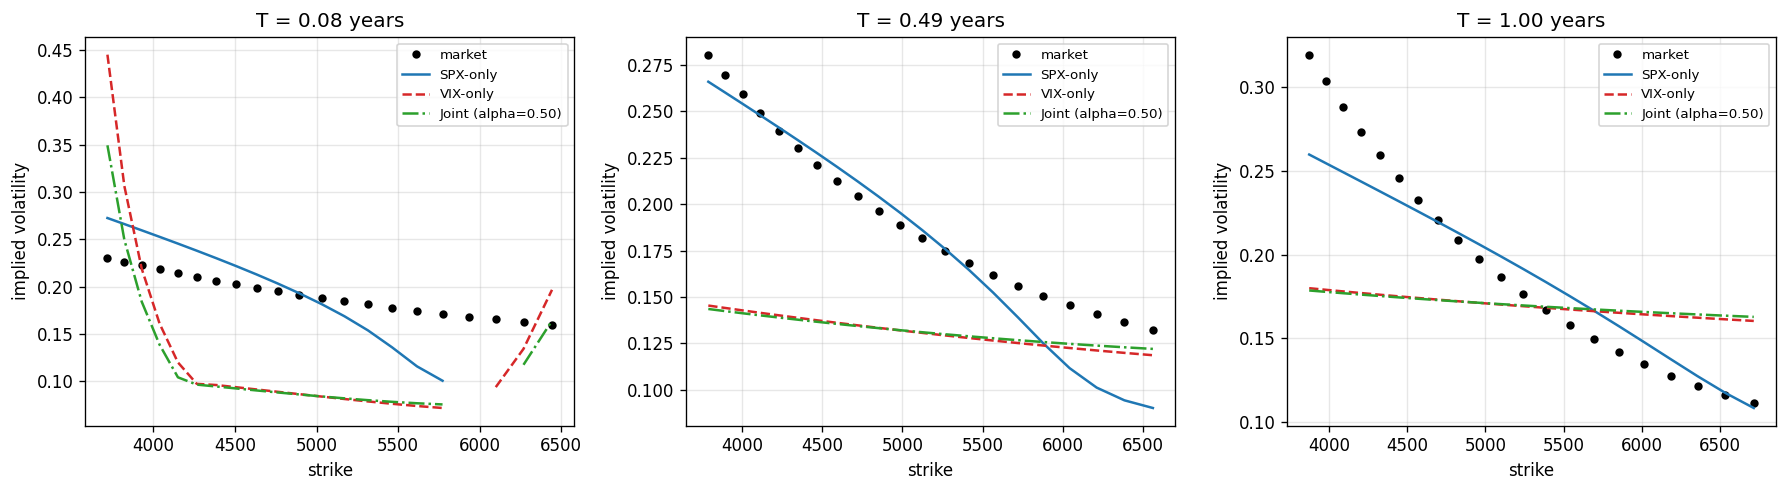

In [12]:
available_maturities = np.sort(snapshot['options']['maturity_years'].unique())
selected = available_maturities[[0, len(available_maturities)//2, -1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
for ax, T in zip(axes, selected):
    sl = snapshot['options'][snapshot['options']['maturity_years'] == T].sort_values('strike')
    ax.plot(sl['strike'], sl['iv_market'], 'ko', label='market', markersize=4)
    for result, ls, color in zip(
        (result_spx, result_vix, result_joint),
        ('-', '--', '-.'),
        ('tab:blue', 'tab:red', 'tab:green'),
    ):
        K, iv = model_smile(result, float(T), snapshot)
        ax.plot(K, iv, ls, color=color, label=result.label)
    ax.set_title(f'T = {T:.2f} years')
    ax.set_xlabel('strike')
    ax.set_ylabel('implied volatility')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / 'spx_smile_comparison.png', dpi=140)
plt.show()

## 6. VIX futures curve diagnostics

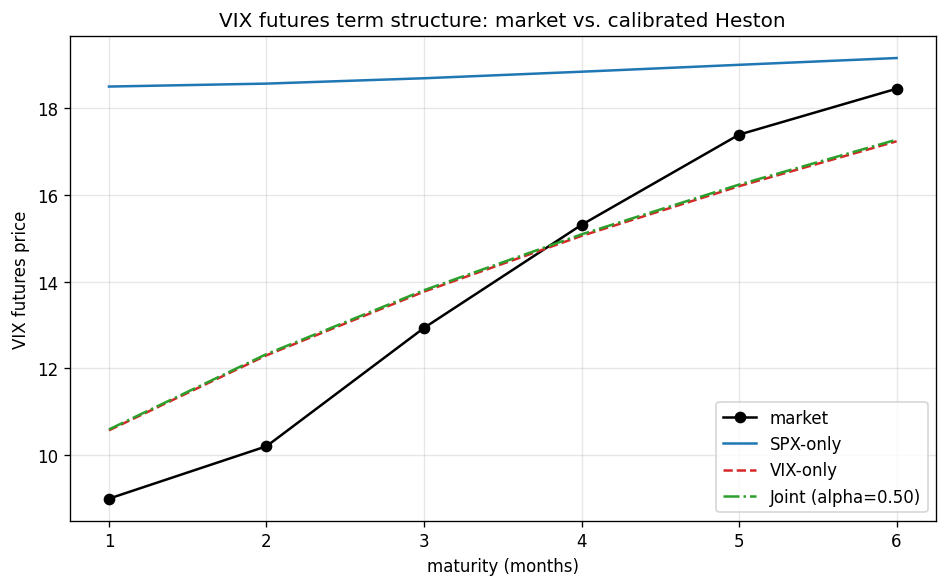

In [13]:
def model_vix_curve(result, maturities, snapshot):
    cir = CIRParams(
        v0=result.params['v0'],
        kappa=result.params['kappa'],
        theta=result.params['theta'],
        sigma_v=result.params['sigma_v'],
    )
    return np.array([
        price_vix_futures_cos(params=cir, maturity=float(T), r=snapshot['rate'])[
            'vix_futures_price'
        ]
        for T in maturities
    ])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(maturities_years * 12, futures_market, 'ko-', label='market', markersize=6)
for result, ls, color in zip(
    (result_spx, result_vix, result_joint),
    ('-', '--', '-.'),
    ('tab:blue', 'tab:red', 'tab:green'),
):
    curve = model_vix_curve(result, maturities_years, snapshot)
    ax.plot(maturities_years * 12, curve, ls, color=color, label=result.label)
ax.set_xlabel('maturity (months)')
ax.set_ylabel('VIX futures price')
ax.set_title('VIX futures term structure: market vs. calibrated Heston')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / 'vix_futures_comparison.png', dpi=140)
plt.show()

## 7. Sensitivity to the joint weight

Sweeping the SPX weight in the joint objective traces out the trade-off between SPX and VIX fit quality.

In [14]:
%%time
weights = [0.25, 0.50, 0.75]
sweep_rows = []
for w in weights:
    r = calibrate_joint(
        spx_targets=spx_targets,
        vix_targets=vix_targets,
        spx_weight=w,
        n_terms=96,
        seeds=(11,),
    )
    fit = evaluate_fit(r, spx_targets, vix_targets, n_terms=96)
    sweep_rows.append({'spx_weight': w, **fit, **r.params})
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(out_dir / 'joint_weight_sweep.csv', index=False)
sweep

CPU times: user 6min 51s, sys: 74.4 ms, total: 6min 51s
Wall time: 5min 37s


,spx_weight,spx_iv_rmse,vix_futures_rmse,kappa,theta,sigma_v,rho,v0
0,0.25,0.056138,1.326477,0.217694,0.241879,0.05,-0.682212,0.005
1,0.50,0.056071,1.327293,0.219996,0.240034,0.05,-0.565933,0.005
2,0.75,0.054684,1.329704,0.224001,0.237709,0.05,-0.990000,0.005


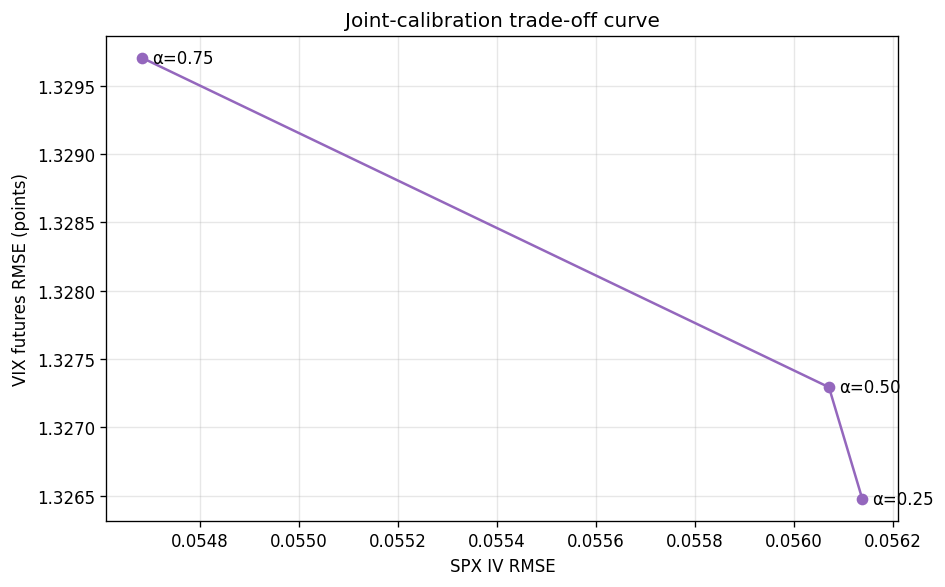

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep['spx_iv_rmse'], sweep['vix_futures_rmse'], 'o-', color='tab:purple')
for _, row in sweep.iterrows():
    ax.annotate(f"\u03B1={row['spx_weight']:.2f}",
                xy=(row['spx_iv_rmse'], row['vix_futures_rmse']),
                xytext=(6, -3), textcoords='offset points')
ax.set_xlabel('SPX IV RMSE')
ax.set_ylabel('VIX futures RMSE (points)')
ax.set_title('Joint-calibration trade-off curve')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / 'tradeoff_curve.png', dpi=140)
plt.show()

## 8. Discussion

The three calibrations give visibly different parameter sets. The SPX-only fit reproduces the equity-side smile well but misses the VIX futures level; the VIX-only fit matches the term structure but produces a flat smile that is far from the market skew. The joint calibration compromises on both, sitting between the two corner solutions.

This is the structural mismatch predicted by W2 Theory §5: a single stochastic variance factor cannot satisfy both targets simultaneously. The required extensions — two-factor stochastic volatility, forward variance models, or rough volatility — are discussed in the future-work section of the paper.

---